In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gpplot as gpp

In [62]:
#read in katsano z-scores
zscored_sgrna_lfcs = pd.read_csv('../../Data/Katsano/zscored_sgrna_lfcs.csv')
katsano_guide_zscores = zscored_sgrna_lfcs[zscored_sgrna_lfcs['Selection Category'] == 'Ensembl Canonical'].copy()
katsano_guide_zscores['Library'] = 'Katsano'
katsano_guide_zscores

,cell_line,Construct Barcode,avg_lfc,n_obs,TSS Coordinate,Target Gene ID,Target Gene Symbol,Selection Category,sgRNA Sequence,neg_ctl_mean,neg_ctl_sd,z_scored_avg_lfc,essential,nonessential,Library
0,A375,AAAAAAAAAAGTGACCTCCC,0.997009,2,chr22:+:39021127,ENSG00000243811.12,APOBEC3D,Ensembl Canonical,AAAAAAAAAAGTGACCTCCC,-0.054895,0.581307,1.809551,False,False,Katsano
1,A375,AAAAAAAAGGGAGAATCGAG,0.012148,2,chr19:+:42269252,ENSG00000079432.9,CIC,Ensembl Canonical,AAAAAAAAGGGAGAATCGAG,-0.054895,0.581307,0.115331,False,False,Katsano
3,A375,AAAAAAAGCTAAAGGTACTA,0.917375,2,chr12:-:10172132,ENSG00000173391.9,OLR1,Ensembl Canonical,AAAAAAAGCTAAAGGTACTA,-0.054895,0.581307,1.672559,False,False,Katsano
4,A375,AAAAAAAGGGAGAATCGAGA,0.035749,2,chr19:+:42269252,ENSG00000079432.9,CIC,Ensembl Canonical,AAAAAAAGGGAGAATCGAGA,-0.054895,0.581307,0.155932,False,False,Katsano
5,A375,AAAAAAATCCAAGTAGCAGA,0.214745,2,chr12:-:51218062,ENSG00000184271.18,POU6F1,Ensembl Canonical,AAAAAAATCCAAGTAGCAGA,-0.054895,0.581307,0.463852,False,False,Katsano
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141145,K562,TTTGTGTCCCCGCAGTGTCG,0.536821,2,chr4:+:94207865,ENSG00000163104.18,SMARCAD1,Ensembl Canonical,TTTGTGTCCCCGCAGTGTCG,0.086601,0.364195,1.236205,False,False,Katsano
141146,K562,TTTGTGTGGAGCCCTCAAGG,0.020741,2,chrX:+:130171962,ENSG00000134594.5,RAB33A,Ensembl Canonical,TTTGTGTGGAGCCCTCAAGG,0.086601,0.364195,-0.180837,False,False,Katsano
141147,K562,TTTGTGTGGTGCCCAGATAG,0.503922,2,chr5:-:137754363,ENSG00000177733.8,HNRNPA0,Ensembl Canonical,TTTGTGTGGTGCCCAGATAG,0.086601,0.364195,1.145874,False,False,Katsano
141148,K562,TTTGTTACAACAGCAATAAA,0.501166,2,chr3:+:184097064,ENSG00000186038.9,HTR3E,Ensembl Canonical,TTTGTTACAACAGCAATAAA,0.086601,0.364195,1.138305,False,True,Katsano


In [63]:
#read in dolcetto guide zscores
dolcetto_guide_zscores = pd.read_csv('../../Data/externalData/Dolcetto/dolcetto_a375_zscored_sgrna_lfcs.csv')
dolcetto_guide_zscores = dolcetto_guide_zscores.rename(columns = {'Gene Symbol':'Target Gene Symbol'})
dolcetto_guide_zscores['Library'] = 'Dolcetto'
dolcetto_guide_zscores

/var/folders/mj/lhpd16ys0cx2wkbhm7s0nfcm0000gp/T/ipykernel_20890/3112077641.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  dolcetto_guide_zscores = pd.read_csv('../../Data/externalData/Dolcetto/dolcetto_a375_zscored_sgrna_lfcs.csv')


,set,cell_line,sgRNA Sequence,avg_lfc,n_obs,set_cell_line,Target Gene Symbol,Gene ID,neg_ctl_mean,neg_ctl_sd,z_scored_avg_lfc,Library
0,A,A375,AAAAAAAAAATACTGAGAGA,0.430747,3,A_A375,GATA3,2625,0.106539,0.437645,0.740801,Dolcetto
1,A,A375,AAAAAAAAGAGGAGGGACGG,-1.446722,3,A_A375,ANKH,56172,0.106539,0.437645,-3.549133,Dolcetto
2,A,A375,AAAAAAACCAGCCTAGCTCG,0.504990,3,A_A375,JAG1,182,0.106539,0.437645,0.910442,Dolcetto
3,A,A375,AAAAAAACTGTCCCGCAACC,0.329861,3,A_A375,MAP1LC3C,440738,0.106539,0.437645,0.510280,Dolcetto
4,A,A375,AAAAAAAGAAAGGGGAAAGG,0.733516,3,A_A375,CCNI,10983,0.106539,0.437645,1.432615,Dolcetto
...,...,...,...,...,...,...,...,...,...,...,...,...
113446,B,A375,ACTCTCTGAGGTGGTCTCAGp999g1,0.228910,3,B_A375,Pseudogene_999,ONE_INTERGENIC_SITE_179,0.106539,0.437645,0.279611,Dolcetto
113447,A,A375,CATGGCTCAGAAAAAGGAATp999g2,0.282946,3,A_A375,Pseudogene_999,ONE_INTERGENIC_SITE_529,0.106539,0.437645,0.403081,Dolcetto
113448,A,A375,CCGCTAGGGGACCCCCTCCGp999g3,-0.303356,3,A_A375,Pseudogene_999,ONE_INTERGENIC_SITE_606,0.106539,0.437645,-0.936592,Dolcetto
113449,A,A375,GTAAGATTTGTTGACACATGp999g4,0.816998,3,A_A375,Pseudogene_999,ONE_INTERGENIC_SITE_1154,0.106539,0.437645,1.623367,Dolcetto


In [183]:
#read in v1 fantom peak annotations
fantom_peak_annotation = pd.read_table('../../Data/FANTOM5/hg38_liftover_CAGE_peaks_phase1+2_annot.txt',skiprows=0)

fantom_peak_bed_file = pd.read_table('../../Data/FANTOM5/hg38_liftover_CAGE_peaks_combined_phase1+2.bed',header=None,
                                    names = ['seqid','start','end','#CAGE_Peak_ID','score','strand','TSS_start','TSS_end','rgb'])

fantom_peaks = fantom_peak_annotation.merge(fantom_peak_bed_file, on = '#CAGE_Peak_ID', how = 'inner')
fantom_peaks['FANTOM_TSS'] = fantom_peaks['TSS_start']
fantom_peaks['Gene_symbol'] = fantom_peaks['Gene_symbol'].fillna('unmapped')
fantom_peaks['max_score'] = fantom_peaks.groupby('Gene_symbol')['score'].transform('max')
fantom_peaks_top_score = fantom_peaks[fantom_peaks['score'] == fantom_peaks['max_score']].copy()

#make sure only one peak per gene was chosen
fantom_peaks_top_score.groupby('Gene_symbol')['#CAGE_Peak_ID'].nunique().value_counts()

1    21850
Name: #CAGE_Peak_ID, dtype: int64

In [184]:
fantom_peaks_top_score['coordinates'] = fantom_peaks_top_score['seqid'] + ':' + fantom_peaks_top_score['strand'] + ':' + fantom_peaks_top_score['TSS_start'].astype(str)
dolcetto_targets = fantom_peaks_top_score[['Gene_symbol','coordinates']].drop_duplicates()
dolcetto_targets.columns = ['gene_name','dolcetto_tss']
dolcetto_targets

,gene_name,dolcetto_tss
0,MTND1P23,chr1:+:629208
4,MTND2P28,chr1:+:630143
11,MTATP8P1,chr1:+:633534
12,MTATP6P1,chr1:+:633860
15,LINC01128,chr1:+:827660
...,...,...
201544,ANKRD30BP2,chr21:+:13060466
201545,SMIM11,chr21:+:34375514
201552,CRYAA,chr21:+:43169032
201594,LINC00313,chr21:-:43478141


In [185]:
katsano_targets = pd.read_csv('../../Data/Katsano/katsano_guide_gene_mapping_GENCODE48.csv')
katsano_targets = katsano_targets[katsano_targets['Selection Category'] == 'Ensembl Canonical'].copy()
katsano_targets = katsano_targets[['Target Gene Symbol','TSS Coordinate']].drop_duplicates().dropna()
katsano_targets.columns = ['gene_name','katsano_tss']
katsano_targets

,gene_name,katsano_tss
0,OR4F5,chr1:+:65419
6,OR4F29,chr1:-:451678
10,OR4F16,chr1:-:686654
14,SAMD11,chr1:+:923923
17,NOC2L,chr1:-:959256
...,...,...
63796,ENSG00000274175,KI270728.1:+:17234
63802,ENSG00000275869,KI270728.1:-:936467
63808,ENSG00000273554,KI270728.1:-:1147868
63811,ENSG00000277836,KI270728.1:+:1270984


In [194]:
katsano_dolcetto_targets_merged = katsano_targets.merge(dolcetto_targets, on = ['gene_name'])
katsano_dolcetto_targets_merged['katsano_tss_pos'] = katsano_dolcetto_targets_merged['katsano_tss'].str.split(':',expand=True)[2].astype(int)
katsano_dolcetto_targets_merged['dolcetto_tss_pos'] = katsano_dolcetto_targets_merged['dolcetto_tss'].str.split(':',expand=True)[2].astype(int)
katsano_dolcetto_targets_merged['same_TSS'] = np.abs(katsano_dolcetto_targets_merged['katsano_tss_pos'] - katsano_dolcetto_targets_merged['dolcetto_tss_pos']) < 1
katsano_dolcetto_targets_merged = katsano_dolcetto_targets_merged[katsano_dolcetto_targets_merged['same_TSS']].copy()
katsano_dolcetto_targets_merged

,gene_name,katsano_tss,dolcetto_tss,katsano_tss_pos,dolcetto_tss_pos,same_TSS
49,RER1,chr1:+:2391841,chr1:+:2391841,2391841,2391841,True
131,FBXO6,chr1:+:11664200,chr1:+:11664200,11664200,11664200,True
214,CDA,chr1:+:20589097,chr1:+:20589097,20589097,20589097,True
228,CELA3A,chr1:+:22001657,chr1:+:22001657,22001657,22001657,True
271,LDLRAP1,chr1:+:25543606,chr1:+:25543606,25543606,25543606,True
...,...,...,...,...,...,...
16228,GLUD2,chrX:+:121047610,chrX:+:121047610,121047610,121047610,True
16229,GRIA3,chrX:+:123184278,chrX:+:123184278,123184278,123184278,True
16244,UTP14A,chrX:+:129906164,chrX:+:129906164,129906164,129906164,True
16282,VGLL1,chrX:+:136532215,chrX:+:136532215,136532215,136532215,True


In [195]:
#essential nonessential annotations
essential_genes = pd.read_csv('../../Data/essentialNonessentialAnnotations/AchillesCommonEssentialControls.csv').Gene.str.split(' ',expand=True)[0]
nonessential_genes = pd.read_csv('../../Data/essentialNonessentialAnnotations/AchillesNonEssentialControls.csv').Gene.str.split(' ',expand=True)[0]

In [196]:
#how many of the targets with the same tss in dolcetto vs katsano are essential? nonessential?
katsano_dolcetto_targets_merged['gene_name'].isin(essential_genes).sum()

27

In [197]:
katsano_dolcetto_targets_merged['gene_name'].isin(nonessential_genes).sum()

14

In [198]:
#combine into one df
combined_guide_df = pd.concat([dolcetto_guide_zscores,katsano_guide_zscores]).reset_index(drop=True)
combined_guide_df['essential'] = combined_guide_df['Target Gene Symbol'].isin(essential_genes)
combined_guide_df['nonessential'] = combined_guide_df['Target Gene Symbol'].isin(nonessential_genes)
combined_guide_df

,set,cell_line,sgRNA Sequence,avg_lfc,n_obs,set_cell_line,Target Gene Symbol,Gene ID,neg_ctl_mean,neg_ctl_sd,z_scored_avg_lfc,Library,Construct Barcode,TSS Coordinate,Target Gene ID,Selection Category,essential,nonessential
0,A,A375,AAAAAAAAAATACTGAGAGA,0.430747,3,A_A375,GATA3,2625,0.106539,0.437645,0.740801,Dolcetto,NaN,NaN,NaN,NaN,False,False
1,A,A375,AAAAAAAAGAGGAGGGACGG,-1.446722,3,A_A375,ANKH,56172,0.106539,0.437645,-3.549133,Dolcetto,NaN,NaN,NaN,NaN,False,False
2,A,A375,AAAAAAACCAGCCTAGCTCG,0.504990,3,A_A375,JAG1,182,0.106539,0.437645,0.910442,Dolcetto,NaN,NaN,NaN,NaN,False,False
3,A,A375,AAAAAAACTGTCCCGCAACC,0.329861,3,A_A375,MAP1LC3C,440738,0.106539,0.437645,0.510280,Dolcetto,NaN,NaN,NaN,NaN,False,False
4,A,A375,AAAAAAAGAAAGGGGAAAGG,0.733516,3,A_A375,CCNI,10983,0.106539,0.437645,1.432615,Dolcetto,NaN,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240242,NaN,K562,TTTGTGTCCCCGCAGTGTCG,0.536821,2,NaN,SMARCAD1,NaN,0.086601,0.364195,1.236205,Katsano,TTTGTGTCCCCGCAGTGTCG,chr4:+:94207865,ENSG00000163104.18,Ensembl Canonical,False,False
240243,NaN,K562,TTTGTGTGGAGCCCTCAAGG,0.020741,2,NaN,RAB33A,NaN,0.086601,0.364195,-0.180837,Katsano,TTTGTGTGGAGCCCTCAAGG,chrX:+:130171962,ENSG00000134594.5,Ensembl Canonical,False,False
240244,NaN,K562,TTTGTGTGGTGCCCAGATAG,0.503922,2,NaN,HNRNPA0,NaN,0.086601,0.364195,1.145874,Katsano,TTTGTGTGGTGCCCAGATAG,chr5:-:137754363,ENSG00000177733.8,Ensembl Canonical,False,False
240245,NaN,K562,TTTGTTACAACAGCAATAAA,0.501166,2,NaN,HTR3E,NaN,0.086601,0.364195,1.138305,Katsano,TTTGTTACAACAGCAATAAA,chr3:+:184097064,ENSG00000186038.9,Ensembl Canonical,False,True


In [199]:
combined_guide_df_subset = combined_guide_df[(combined_guide_df['Target Gene Symbol'].isin(katsano_dolcetto_targets_merged['gene_name']))].copy()

In [200]:
combined_guide_df_subset

,set,cell_line,sgRNA Sequence,avg_lfc,n_obs,set_cell_line,Target Gene Symbol,Gene ID,neg_ctl_mean,neg_ctl_sd,z_scored_avg_lfc,Library,Construct Barcode,TSS Coordinate,Target Gene ID,Selection Category,essential,nonessential
102,A,A375,AAAAGATGAAGTTATATGTT,-0.192982,3,A_A375,FPR3,2359,0.106539,0.437645,-0.684393,Dolcetto,NaN,NaN,NaN,NaN,False,False
135,A,A375,AAAAGTATCAGGAGTTGTCA,0.320313,3,A_A375,SOX2,6657,0.106539,0.437645,0.488463,Dolcetto,NaN,NaN,NaN,NaN,False,False
266,A,A375,AAACTGCAAAGATGTTTGCC,0.411149,3,A_A375,HABP2,3026,0.106539,0.437645,0.696021,Dolcetto,NaN,NaN,NaN,NaN,False,False
287,A,A375,AAACTTTCACCTCCTCAGCC,0.590496,3,A_A375,ZIC1,7545,0.106539,0.437645,1.105821,Dolcetto,NaN,NaN,NaN,NaN,False,False
288,A,A375,AAACTTTCCGCCCGGCCCTG,0.347928,3,A_A375,LDLRAP1,26119,0.106539,0.437645,0.551564,Dolcetto,NaN,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239876,NaN,K562,TTGGTAAGGAAATAAAGACA,-4.214097,2,NaN,RPL34,NaN,0.086601,0.364195,-11.808776,Katsano,TTGGTAAGGAAATAAAGACA,chr4:+:108620576,ENSG00000109475.18,Ensembl Canonical,False,False
239887,NaN,K562,TTGGTCCTCCTAGTAAACTT,0.523962,2,NaN,HABP2,NaN,0.086601,0.364195,1.200898,Katsano,TTGGTCCTCCTAGTAAACTT,chr10:+:113553053,ENSG00000148702.15,Ensembl Canonical,False,False
240050,NaN,K562,TTTAGCACTCCGCCACCGAG,-3.141617,2,NaN,USP1,NaN,0.086601,0.364195,-8.863979,Katsano,TTTAGCACTCCGCCACCGAG,chr1:+:62437049,ENSG00000162607.13,Ensembl Canonical,False,False
240102,NaN,K562,TTTCCGGCCGGTCCCCATGG,0.101246,2,NaN,ERGIC3,NaN,0.086601,0.364195,0.040212,Katsano,TTTCCGGCCGGTCCCCATGG,chr20:+:35542078,ENSG00000125991.21,Ensembl Canonical,False,False


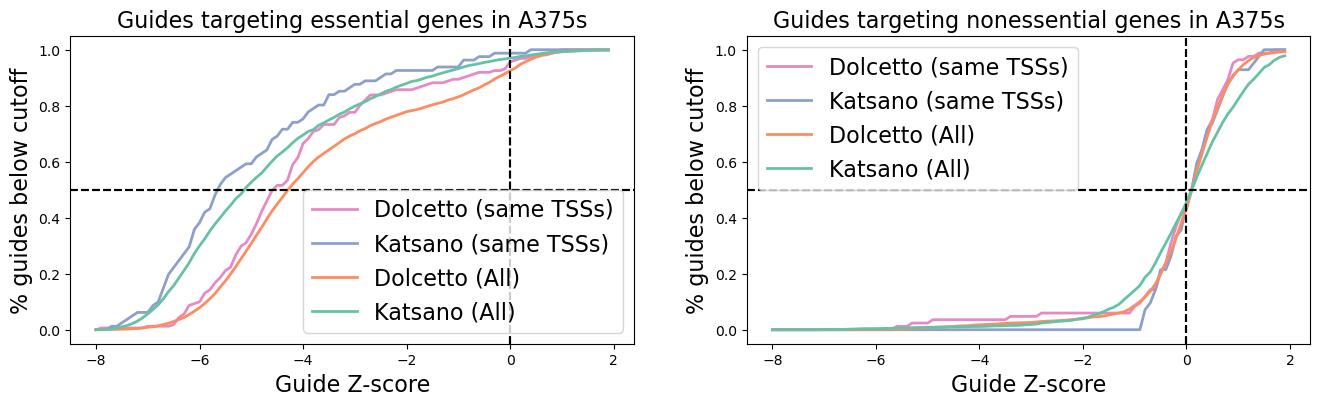

In [201]:
a375_df = combined_guide_df_subset[(combined_guide_df_subset['cell_line'] == 'A375')].copy()

combined_ess_guide_df = a375_df[a375_df['essential']].copy()
combined_noness_guide_df = a375_df[a375_df['nonessential']].copy()
zscore_cutoffs = np.arange(-8,2,0.1)

fig, ax = plt.subplots(1,2,figsize=(16,4))

color_map = {'Katsano':sns.color_palette("Set2")[2],'Dolcetto':sns.color_palette("Set2")[3]}

#essential
for group,df in combined_ess_guide_df.groupby('Library'):
    prop_below_cutoff_list = []
    for cutoff in zscore_cutoffs:
        prop_below_cutoff = (df['z_scored_avg_lfc'] < cutoff).mean()
        prop_below_cutoff_list.append(prop_below_cutoff)
    ax[0].plot(zscore_cutoffs, prop_below_cutoff_list, color = color_map[group],label = group + ' (same TSSs)',linewidth = 2)
    ax[0].legend()

ax[0].set_xlabel("Guide Z-score",fontsize=16)
ax[0].set_ylabel("% guides below cutoff",fontsize=16)
ax[0].set_title("Guides targeting essential genes in A375s",fontsize=16)
ax[0].legend(title = '', fontsize=16)
ax[0].axvline(x=0, color='black', linestyle='--')
ax[0].axhline(y=0.5, color='black', linestyle='--')

#nonessential
for group,df in combined_noness_guide_df.groupby('Library'):
    prop_below_cutoff_list = []
    for cutoff in zscore_cutoffs:
        prop_below_cutoff = (df['z_scored_avg_lfc'] < cutoff).mean()
        prop_below_cutoff_list.append(prop_below_cutoff)
    ax[1].plot(zscore_cutoffs, prop_below_cutoff_list, color = color_map[group], label = group + ' (same TSSs)', linewidth = 2)
    ax[1].legend()

ax[1].set_xlabel("Guide Z-score",fontsize=16)
ax[1].set_ylabel("% guides below cutoff",fontsize=16)
ax[1].set_title("Guides targeting nonessential genes in A375s",fontsize=16)
ax[1].legend(title = '', fontsize=16)
ax[1].axvline(x=0, color='black', linestyle='--')
ax[1].axhline(y=0.5, color='black', linestyle='--')


#now add the lines with ALL genes
a375_df = combined_guide_df[(combined_guide_df['cell_line'] == 'A375')].copy()

combined_ess_guide_df = a375_df[a375_df['essential']].copy()
combined_noness_guide_df = a375_df[a375_df['nonessential']].copy()
zscore_cutoffs = np.arange(-8,2,0.1)

color_map = {'Katsano':sns.color_palette("Set2")[0],'Dolcetto':sns.color_palette("Set2")[1]}

#essential
for group,df in combined_ess_guide_df.groupby('Library'):
    prop_below_cutoff_list = []
    for cutoff in zscore_cutoffs:
        prop_below_cutoff = (df['z_scored_avg_lfc'] < cutoff).mean()
        prop_below_cutoff_list.append(prop_below_cutoff)
    ax[0].plot(zscore_cutoffs, prop_below_cutoff_list, color = color_map[group], label = group + ' (All)', linewidth = 2)
    ax[0].legend()

ax[0].set_xlabel("Guide Z-score",fontsize=16)
ax[0].set_ylabel("% guides below cutoff",fontsize=16)
ax[0].set_title("Guides targeting essential genes in A375s",fontsize=16)
ax[0].legend(title = '', fontsize=16)
ax[0].axvline(x=0, color='black', linestyle='--')
ax[0].axhline(y=0.5, color='black', linestyle='--')

#nonessential
for group,df in combined_noness_guide_df.groupby('Library'):
    prop_below_cutoff_list = []
    for cutoff in zscore_cutoffs:
        prop_below_cutoff = (df['z_scored_avg_lfc'] < cutoff).mean()
        prop_below_cutoff_list.append(prop_below_cutoff)
    ax[1].plot(zscore_cutoffs, prop_below_cutoff_list, color = color_map[group], label = group + ' (All)', linewidth = 2)
    ax[1].legend()

ax[1].set_xlabel("Guide Z-score",fontsize=16)
ax[1].set_ylabel("% guides below cutoff",fontsize=16)
ax[1].set_title("Guides targeting nonessential genes in A375s",fontsize=16)
ax[1].legend(title = '', fontsize=16)
ax[1].axvline(x=0, color='black', linestyle='--')
ax[1].axhline(y=0.5, color='black', linestyle='--')

gpp.savefig('../../Figures/Figure 7/katsano_dolcetto_cum_dist_plots_same_tsss_vs_all_genes.pdf',dpi=300, bbox_inches='tight')